In [1]:
from utils import * 
import os 
import subprocess
import gfapy
import tqdm 

%load_ext autoreload 
%autoreload 2

In [2]:
READ_LENGTH = 150

In [3]:
LOCATION = 'zhuji_petroleum_contaminated_soil'
BIOTITE_OUTPUT_DIR = os.path.join('/home/philippar', LOCATION)
LOCAL_OUTPUT_DIR = os.path.join('.', LOCATION)
os.makedirs(LOCAL_OUTPUT_DIR, exist_ok=True)

FORWARD_READS_PATH = '/groups/banfield/scratch/projects/environmental/RES/int/LDS/sandpiper_not_in_Logan/SRR29383098_trim_clean.PE.1.fastq.gz'
REVERSE_READS_PATH = '/groups/banfield/scratch/projects/environmental/RES/int/LDS/sandpiper_not_in_Logan/SRR29383098_trim_clean.PE.2.fastq.gz'


In [4]:
# Low coverage and high levels of strain variation in the Betazoid genomes in some samples (zhuji_petroleum_contaminated_soil, nantong_groundwater)
# seems to be resulting in scaffolds which are poorly-supported by mapped reads, chimeric, have uneven coverage, and are difficult to resolve manually in Geneious. 
# To improve the fidelity of the assembled scaffolds, we implement a local assembly (i.e. targeted assembly) approach. 

# Uding de novo local assembly has the advantages of (1) reducing computational cost, (2) generating a lower-complexity assembly graph which can be directly 
# visualized and interpreted, (3) making assemblers less prone to collapsing strain variation for the sake of simplicity, (4) mitigating effects of edges being
# drawn between reads from unrelated genomes, etc. [1]. 

# We implement the following pipeline:
# (1) Collect an initial set of validated seed contigs. 
# (2) Construct a BLAST database using the contigs from the project. 
# (3) Split contigs into chunks.*
# (4) Align the contig chunks against the BLAST database.
# Repeat steps 3 and 4 with the newly-recruited contigs until no more good hits are recruited. 
# (3) Map reads to the final set of scaffolds.
# (4) Use recruited reads for de novo local assembly, including generating an assembly graph. 
#   ** Might need to adjust assembly parameters!
# (5) Process the assembly graph to produce a set of strain-aware contigs supported by mapped reads. 

# [1] https://www.frontiersin.org/journals/genetics/articles/10.3389/fgene.2019.00957/
# [2] https://rrwick.github.io/Bandage/ 

# * See notes on BLAST search below. 

In [5]:
# (2) Collect an initial set of validated seed contigs. 

GGKBASE_CONTIG_PATH = '../data/blast/databases/Petroleum-contam_soil_SRR29383098.contigs.fasta' # Path to contigs downloaded from ggKbase.
GGKBASE_CONTIG_IDS = ['Petroleum-contam_soil_SRR29383098_scaffold_10782', 'Petroleum-contam_soil_SRR29383098_scaffold_8133', 'Petroleum-contam_soil_SRR29383098_scaffold_2108', 'Petroleum-contam_soil_SRR29383098_scaffold_21309', 'Petroleum-contam_soil_SRR29383098_scaffold_45918', 'Petroleum-contam_soil_SRR29383098_scaffold_7625', 'Petroleum-contam_soil_SRR29383098_scaffold_8328']

In [6]:

BLASTN_DATABASE_DIR = '../data/blast/databases/'
BLASTN_DATABASE_NAME = 'Petroleum-contam_soil_SRR29383098'
BLASTN_DATABASE_PATH = os.path.join(BLASTN_DATABASE_DIR, BLASTN_DATABASE_NAME)

MAKEBLASTDB_PARAMS = dict()
MAKEBLASTDB_PARAMS['-in'] = GGKBASE_CONTIG_PATH
MAKEBLASTDB_PARAMS['-dbtype'] = 'nucl'
MAKEBLASTDB_PARAMS['-title'] = BLASTN_DATABASE_NAME
MAKEBLASTDB_PARAMS['-out'] = BLASTN_DATABASE_PATH

BLASTN_OUTPUT_DIR = os.path.join(LOCAL_OUTPUT_DIR, 'blast')
BLASTN_QUERY_PATH_PATTERN = os.path.join(BLASTN_OUTPUT_DIR, 'query.{iteration}.fasta')
BLASTN_OUTPUT_PATH_PATTERN = os.path.join(BLASTN_OUTPUT_DIR, 'output.{iteration}.tsv')
os.makedirs(LOCAL_OUTPUT_DIR, exist_ok=True)

BLASTN_PARAMS = dict()
BLASTN_PARAMS['-db'] = BLASTN_DATABASE_PATH
BLASTN_PARAMS['-outfmt'] = '"6 qseqid sseqid pident length mismatch gapopen qstart qend sstart send evalue bitscore"'

In [7]:
# (1) Construct a BLAST database using the contigs from the project. 

def check_blast_database(database_path):
    return os.path.exists(f'{database_path}.ndb')

if not check_blast_database(BLASTN_DATABASE_PATH):
    cmd = ' '.join(['makeblastdb'] + [f'{param} {value}' for param, value in MAKEBLASTDB_PARAMS.items()])
    result = subprocess.run(cmd, shell=True, check=True, capture_output=True)
    if result.returncode == 0:
        print(f'Created BLAST database at {BLASTN_DATABASE_PATH}.')
    else:
        print(f'Failed to create BLAST database.')
else:
    print(f'Using existing BLAST database at {BLASTN_DATABASE_PATH}')

Using existing BLAST database at ../data/blast/databases/Petroleum-contam_soil_SRR29383098


In [8]:
def blastn_load_output(path, min_alignment_length:int=50, min_percent_identity:float=75, max_gc_percent:float=35):
    '''Load the BLAST results and apply the following filters:
    (1) self_alignments: Remove self-hits, i.e. hits to the parent contig from which the chunk was derived.
    (2) high_gc_content: Remove contigs with GC content exceeding max_gc_content. 
    (3) short_alignments: Remove alignments shorter than min_alignment_length. 
    (4) low_percent_identity: Remove alignments with percent_identity less than min_percent_identity. 
    '''
    
    fields = ['query_id', 'subject_id', 'percent_identity', 'alignment_length', 'num_mismatches', 'num_gaps', 'query_start', 'query_end', 'subject_start', 'subject_end', 'e_value', 'bit_score']
    df = pd.read_csv(path, sep='\t', names=fields)
    df['query_parent_id'] = [query_id.split('.')[0] for query_id in df.query_id]
    df['subject_seq'] = df.subject_id.map(load_seqs(df.subject_id.unique(), path=GGKBASE_CONTIG_PATH))
    df['subject_gc_percent'] = 100 * (df.subject_seq.str.count('C') + df.subject_seq.str.count('G')) / df.subject_seq.apply(len)

    filters = dict() # Filters here are the FAILING conditions, so want to remove hits that fail ANY of these, or pass ALL of them. 
    filters['self_alignments'] = df.subject_id == df.query_parent_id
    filters['high_gc_content'] = df.subject_gc_percent > max_gc_percent
    filters['short_alignments'] = df.alignment_length < min_alignment_length
    filters['low_percent_identity'] = df.percent_identity < min_percent_identity
    
    mask = None
    for name, mask_ in filters.items():
        mask = ~mask_ if (mask is None) else mask & (~mask_)
        print(f'blastn_load_output: {mask_.sum()} hits failing condition {name}.')

    print(f'blastn_load_output: {mask.sum()} of {len(df)} hits pass all filters.')
    return df[mask].copy() 


def blastn_split_queries(contig_df, chunk_size:int=300, min_chunk_size:int=50):
    '''Split each contig into shorter, non-overlapping chunks for querying against the BLAST database.
    
    :param contig_df : A DataFrame containing the query contigs. 
    :param chunk_size : Size of chunks into which each contig will be divided. 
    :param min_chunk_size : Minimum chunk size, for cases where the contig is not divided evenly. 
    '''
    df = list()
    for row in contig_df.itertuples():
        seq = row.seq 
        chunks = [seq[i:i + chunk_size] for i in range(0, len(seq), chunk_size)]
        chunks = [chunk for chunk in chunks if len(chunk) > min_chunk_size]
        chunk_ids = [row.Index + f'.{i + 1}' for i in range(len(chunks))]
        df += [{'id':chunk_id, 'seq':chunk} for chunk_id, chunk in zip(chunk_ids, chunks)]
    df = pd.DataFrame(df).set_index('id')
    print(f'blastn_split_queries: Split {len(contig_df)} contigs into {len(df)} chunks between {df.seq.apply(len).min()} and {df.seq.apply(len).max()} bp in length.')
    return df


In [9]:
def blastn_search(contig_ids, iteration:int=0):

    query_path = BLASTN_QUERY_PATH_PATTERN.format(iteration=iteration)
    output_path = BLASTN_OUTPUT_PATH_PATTERN.format(iteration=iteration)

    if not os.path.exists(output_path):

        BLASTN_PARAMS['-query'] = query_path
        BLASTN_PARAMS['-out'] = output_path

        # (3) Split contigs into chunks.

        contig_df = FASTAFile.from_file(GGKBASE_CONTIG_PATH, filter_=lambda record : record.id in contig_ids).to_df()
        contig_df = blastn_split_queries(contig_df)
        FASTAFile.from_df(contig_df).write(query_path)

        # (4) Align the contig chunks against the BLAST database.

        cmd = ' '.join(['blastn'] + [f'{param} {value}' for param, value in BLASTN_PARAMS.items()])
        subprocess.run(cmd, shell=True, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        
    output_df = blastn_load_output(output_path)
    contig_ids = list(set(contig_ids + output_df.subject_id.unique().tolist()))
    return contig_ids 

In [10]:
contig_ids = GGKBASE_CONTIG_IDS 
print('NUMBER OF CONTIGS:', len(contig_ids), end='\n\n')

for i in range(3):
    print(f'ITERATION {i}', end='\n\n')
    contig_ids = blastn_search(contig_ids, iteration=i)
    print('NUMBER OF CONTIGS:', len(contig_ids), end='\n\n')

contig_file = FASTAFile.from_file(GGKBASE_CONTIG_PATH, filter_=lambda record : record.id in contig_ids)
contig_file.write(os.path.join(LOCAL_OUTPUT_DIR, 'seeds.fasta'))



NUMBER OF CONTIGS: 7

ITERATION 0

blastn_load_output: 108 hits failing condition self_alignments.
blastn_load_output: 0 hits failing condition high_gc_content.
blastn_load_output: 1 hits failing condition short_alignments.
blastn_load_output: 0 hits failing condition low_percent_identity.
blastn_load_output: 78 of 187 hits pass all filters.
NUMBER OF CONTIGS: 15

ITERATION 1

blastn_load_output: 174 hits failing condition self_alignments.
blastn_load_output: 0 hits failing condition high_gc_content.
blastn_load_output: 2 hits failing condition short_alignments.
blastn_load_output: 0 hits failing condition low_percent_identity.
blastn_load_output: 140 of 315 hits pass all filters.
NUMBER OF CONTIGS: 20

ITERATION 2

blastn_load_output: 197 hits failing condition self_alignments.
blastn_load_output: 0 hits failing condition high_gc_content.
blastn_load_output: 2 hits failing condition short_alignments.
blastn_load_output: 0 hits failing condition low_percent_identity.
blastn_load_output

In [11]:
# (3) Map reads to the final set of scaffolds.
#   * Use permissive mapping settings in order to capture as much diversity as possible. 
BBMAP_PARAMS = dict()
BBMAP_PARAMS['local'] = 'f'
BBMAP_PARAMS['minid'] = 0.8
BBMAP_PARAMS['idfilter'] = 0.8
BBMAP_PARAMS['pairedonly'] = 'f'

cmd, BBMAP_OUTPUT_PATH = get_bbmap_command(os.path.join(BIOTITE_OUTPUT_DIR, 'seeds.fasta'), forward_reads_path=FORWARD_READS_PATH, output_dir=BIOTITE_OUTPUT_DIR, reverse_reads_path=REVERSE_READS_PATH, **BBMAP_PARAMS)
print(cmd, end='\n\n')

# (4) Use recruited reads for de novo local assembly, including generating an assembly graph. 

READS_PATH_PATTERN = os.path.join(BIOTITE_OUTPUT_DIR, 'reads.PE.{paired_end}.fastq.gz')

SAMTOOLS_PARAMS = dict()
SAMTOOLS_PARAMS['-1'] = READS_PATH_PATTERN.format(paired_end=1)
SAMTOOLS_PARAMS['-2'] = READS_PATH_PATTERN.format(paired_end=2)
SAMTOOLS_PARAMS['-0'] = '/dev/null' 
SAMTOOLS_PARAMS['-s'] = READS_PATH_PATTERN.format(paired_end=0) # Keep the singleton reads
SAMTOOLS_PARAMS['-n'] = BBMAP_OUTPUT_PATH

METASPADES_OUTPUT_DIR = os.path.join(BIOTITE_OUTPUT_DIR, 'assembly')
METASPADES_PARAMS = dict()
METASPADES_PARAMS['-1'] = READS_PATH_PATTERN.format(paired_end=1)
METASPADES_PARAMS['-2'] = READS_PATH_PATTERN.format(paired_end=2)
METASPADES_PARAMS['-o'] = METASPADES_OUTPUT_DIR
METASPADES_PARAMS['-s'] = READS_PATH_PATTERN.format(location=LOCATION, paired_end=0) # Keep the singleton reads

cmd = ' '.join(['samtools fastq'] + [f'{param} {value}' for param, value in SAMTOOLS_PARAMS.items()])
print(cmd, end='\n\n')

cmd = ' '.join(['metaspades.py'] + [f'{param} {value}' for param, value in METASPADES_PARAMS.items()])
print(cmd)



get_bbmap_command: Using the following mapping settings:
	local: f
	pairedonly: f
	ambiguous: random
	minid: 0.8
	idfilter: 0.8
	editfilter: -1
bbmap.sh local=f pairedonly=f ambiguous=random minid=0.8 idfilter=0.8 editfilter=-1 out=stdout.sam threads=64 pigz=t unpigz=t in1=/groups/banfield/scratch/projects/environmental/RES/int/LDS/sandpiper_not_in_Logan/SRR29383098_trim_clean.PE.1.fastq.gz in2=/groups/banfield/scratch/projects/environmental/RES/int/LDS/sandpiper_not_in_Logan/SRR29383098_trim_clean.PE.2.fastq.gz ref=/home/philippar/zhuji_petroleum_contaminated_soil/seeds.fasta nodisk | shrinksam | sambam > /home/philippar/zhuji_petroleum_contaminated_soil/seeds.bam

samtools fastq -1 /home/philippar/zhuji_petroleum_contaminated_soil/reads.PE.1.fastq.gz -2 /home/philippar/zhuji_petroleum_contaminated_soil/reads.PE.2.fastq.gz -0 /dev/null -s /home/philippar/zhuji_petroleum_contaminated_soil/reads.PE.0.fastq.gz -n /home/philippar/zhuji_petroleum_contaminated_soil/seeds.bam

metaspades.py 

In [17]:
# (5) Process the assembly graph to produce a set of strain-aware contigs supported by mapped reads.

ASSEMBLY_GRAPH_PATH = os.path.join(LOCAL_OUTPUT_DIR, 'assembly', 'assembly_graph_with_scaffolds.gfa')
ASSEMBLY_GRAPH_PATH = os.path.join(LOCAL_OUTPUT_DIR, 'assembly', 'assembly_graph_after_simplification.gfa')
ASSEMBLY_GRAPH_FASTA_PATH = os.path.join(LOCAL_OUTPUT_DIR, 'graph.fasta')
# PATHS_PATH = os.path.join(LOCAL_OUTPUT_DIR, 'paths.fasta')

gfa_file = GFAFile.from_file(ASSEMBLY_GRAPH_PATH)

def get_graph_sequences(gfa_file, path:str=None, delta:int=100, overlap_length:int=55):

    df = list()

    for node_id, data in gfa_file.graph.nodes(data=True):
        df.append({'id':f'node_{node_id}', 'seq':data['seq']})
    for from_node_id, to_node_id in gfa_file.graph.edges():

        from_node_length, _ = len(gfa_file.graph.nodes[from_node_id]['seq']), len(gfa_file.graph.nodes[to_node_id]['seq'])
        
        seq = gfa_file.get_seq_from_path([from_node_id, to_node_id])
        seq = seq[max(from_node_length - delta, 0):(from_node_length - overlap_length + delta)]
        
        df.append({'id':f'edge_{from_node_id}_{to_node_id}', 'seq':seq})
    
    df = pd.DataFrame(df).set_index('id')
    FASTAFile.from_df(df).write(path)

    return df

graph_df = get_graph_sequences(gfa_file, path=ASSEMBLY_GRAPH_FASTA_PATH)

BBMAP_PARAMS = dict()
BBMAP_PARAMS['local'] = 't' # Allow local alignments to allow for overhangs
BBMAP_PARAMS['pairedonly'] = 'f'
BBMAP_PARAMS['maxsites'] = len(graph_df)
BBMAP_PARAMS['idfilter'] = 0.95 
BBMAP_PARAMS['minid'] = 0.9
BBMAP_PARAMS['ambiguous'] = 'all'

cmd, BBMAP_OUTPUT_PATH = get_bbmap_command(os.path.join(BIOTITE_OUTPUT_DIR, 'graph.fasta'), forward_reads_path=FORWARD_READS_PATH, output_dir=BIOTITE_OUTPUT_DIR, reverse_reads_path=REVERSE_READS_PATH, **BBMAP_PARAMS)
print(cmd)

GFAFile._get_nodes_with_self_edges: Found 4 nodes with self-edges.
GFAFile._remove_singleton_nodes_with_self_edges: Removed 4 singleton nodes with self-edges.
GFAFile._remove_cycles: Removed 2 nodes from the graph: ['537+', '537-']
get_bbmap_command: Using the following mapping settings:
	local: t
	pairedonly: f
	ambiguous: all
	minid: 0.9
	idfilter: 0.95
	editfilter: -1
	maxsites: 566
bbmap.sh local=t pairedonly=f ambiguous=all minid=0.9 idfilter=0.95 editfilter=-1 maxsites=566 out=stdout.sam threads=64 pigz=t unpigz=t in1=/groups/banfield/scratch/projects/environmental/RES/int/LDS/sandpiper_not_in_Logan/SRR29383098_trim_clean.PE.1.fastq.gz in2=/groups/banfield/scratch/projects/environmental/RES/int/LDS/sandpiper_not_in_Logan/SRR29383098_trim_clean.PE.2.fastq.gz ref=/home/philippar/zhuji_petroleum_contaminated_soil/graph.fasta nodisk | shrinksam | sambam > /home/philippar/zhuji_petroleum_contaminated_soil/graph.bam


BamFile.to_alignments: Discarded 487 alignments with internal clips or max_n_errors > 5.
edge_3+_597- 0.0 107
edge_3-_879- 0.0 111
edge_3-_1261- 0.993103448275862 145
edge_5-_359+ 0.0 110
edge_11+_25- 0.0 124
edge_11+_85+ 3.0206896551724136 145
edge_11-_351- 0.0 104
edge_13+_401- 0.0 104
edge_13-_662+ 2.8620689655172415 145
edge_13-_1361- 0.0 145
edge_19+_1255- 0.0 145
edge_19-_133+ 0.0 145
edge_23+_401+ 0.0 104
edge_25-_541- 0.0 21
edge_27+_1159- 3.8344827586206898 145
edge_27+_1343- 0.8896551724137931 145
edge_27-_41+ 0.0 145
edge_27-_2475- 0.0 145
edge_33-_249+ 2.7241379310344827 145
edge_39-_51- 0.0 14
edge_41+_457- 0.0 105
edge_41-_27+ 0.0 145
edge_47+_133+ 0.0 145
edge_47-_1255- 2.986206896551724 145
edge_51+_39+ 0.0 42
edge_53+_1231+ 0.9655172413793104 145
edge_53+_3615+ 0.0 145
edge_53-_39- 2.931297709923664 131
edge_56+_1231- 8.696551724137931 145
edge_56+_3615- 3.793103448275862 145
edge_56-_1047+ 0.0 143
edge_57-_39- 1.0 131
edge_63+_267+ 2.889655172413793 145
edge_63-_597- 

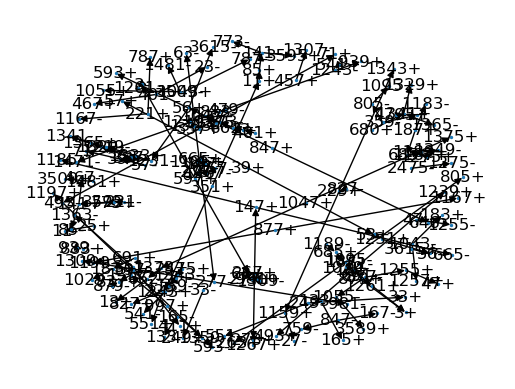

In [ ]:
max_n_errors = 5
max_end_gap_length = int(READ_LENGTH * 0.5)
max_internal_gap_length = 1

alignments = BamFile.from_file(os.path.join(LOCAL_OUTPUT_DIR, 'graph.bam')).to_alignments(max_n_errors=max_n_errors)
alignments = {id_:alignment for id_, alignment in alignments.items() if ('edge' in id_)}

for edge_id, alignment in alignments.items():
    print(edge_id, alignment.mean(), len(alignment))
    if alignment.mean() == 0:
        from_node_id, to_node_id = edge_id.split('_')[1:]
        gfa_file.graph.remove_edge(from_node_id, to_node_id)

gfa_file.draw()

In [32]:
gfa_file.get_all_paths('test.fasta')

GFAFile: Found 159 source nodes.


GFAFile.get_all_paths: Computing all paths starting from 57-. Longest path is 2849 base pairs.:   0%|          | 0/159 [00:00<?, ?it/s]

GFAFile.get_all_paths: Computing all paths starting from 3615+. Longest path is 4446 base pairs.: 100%|██████████| 159/159 [00:00<00:00, 433.43it/s]


GFAFile.get_all_paths: Wrote 206 unique paths to test.fasta.


In [14]:
max_n_errors = 1
max_end_gap_length = int(READ_LENGTH * 0.5)
max_internal_gap_length = 1

alignments = BamFile.from_file(os.path.join(LOCAL_OUTPUT_DIR, 'nodes.bam')).to_alignments(max_n_errors=max_n_errors)

removed_node_ids = list()

for node_id, alignment in alignments.items():
    if np.all(alignment > 0):
        continue

    left_gap_length = len(alignment) - len(np.trim_zeros(alignment, trim='f'))
    right_gap_length = len(alignment) - len(np.trim_zeros(alignment, trim='b'))

    if np.all(alignment == 0):
        print('Removing node', node_id, f'(length {len(alignment)}): No reads aligned.')
        gfa_file.remove_node(node_id)
    elif (left_gap_length > max_end_gap_length) or (right_gap_length > max_end_gap_length):
        print('Removing node', node_id, f'(length {len(alignment)}): Left gap is {left_gap_length} and right gap is {right_gap_length}.')
        gfa_file.remove_node(node_id)
    elif (np.trim_zeros(alignment) == 0).sum() > max_internal_gap_length:
        print('Removing node', node_id, f'(length {len(alignment)}): Found {(np.trim_zeros(alignment) == 0).sum()} uncovered internal bases.')
        gfa_file.remove_node(node_id)

gfa_file.get_all_paths(PATHS_PATH)

BamFile.to_alignments: Discarded 1383 alignments with internal clips or max_n_errors > 1.
Removing node 1349 (length 1676): Found 155 uncovered internal bases.
Removing node 1471 (length 510): Left gap is 85 and right gap is 0.
Removing node 165 (length 155): No reads aligned.
Removing node 223 (length 298): Left gap is 88 and right gap is 0.
Removing node 229 (length 268): Left gap is 98 and right gap is 0.
Removing node 33 (length 2766): Left gap is 188 and right gap is 0.
Removing node 71 (length 393): Left gap is 0 and right gap is 125.
Removing node 785 (length 3258): Found 16 uncovered internal bases.
Removing node 875 (length 259): Left gap is 0 and right gap is 90.
GFAFile: Found 83 source nodes.


GFAFile.get_all_paths: Computing all paths starting from 939-. Longest path is 12824 base pairs.:  45%|████▍     | 37/83 [01:22<01:42,  2.23s/it]


KeyboardInterrupt: 

In [ ]:
MMSEQS_TMP_DIR = './tmp/'
MMSEQS_OUTPUT_PATH = os.path.join(LOCAL_OUTPUT_DIR, 'paths')

cmd = f'mmseqs easy-cluster {PATHS_PATH} {MMSEQS_OUTPUT_PATH} {MMSEQS_TMP_DIR}  --min-seq-id 0.99 --cov-mode 5 --min-aln-len 1000'
print(cmd)

mmseqs easy-cluster ./zhuji_petroleum_contaminated_soil/paths.fasta ./zhuji_petroleum_contaminated_soil/paths ./tmp/  --min-seq-id 0.99 --cov-mode 5 --min-aln-len 1000


In [ ]:
# def remove_multimappings(bam_df):
#     '''Remove mappings of the same read to the same reference contig, i.e. BAM entries where ref_id and read_id are duplicated.'''
#     mask = bam_df.duplicated(['read_id', 'read_1', 'read_2', 'ref_id'], keep='first')
#     if mask.sum() > 0:
#         print(f'remove_multimappings: Removing {mask.sum()} mappings of the same read to a reference.')
#         bam_df = bam_df[~mask].copy()
#     return bam_df


# def get_proper_pairs(bam_df:pd.DataFrame):
#     '''Select only aligned read pairs where both reads map to the same reference. This is not enforced by pairedonly=t, which only 
#     enforces that each member of a pair maps to at least one of the provided contigs.'''
#     bam_df = remove_multimappings(bam_df)
#     mask = bam_df.duplicated((['read_id', 'ref_id']), keep=False) # With keep='none', will return True for all that are duplicated. 
#     if (~mask).sum() > 0:
#         print(f'get_proper_pairs: Removing {(~mask).sum()} mappings with unplaced pairs.')
#         bam_df = bam_df[mask].copy()
#     return bam_df


# def get_supported_paths_1(bam_df, path_df, min_coverage:float=5, min_path_length:int=MIN_PATH_LENGTH):
    
#     # bam_df = get_proper_pairs(bam_df)

#     path_df = path_df.copy()
#     path_df['length'] = path_df.seq.apply(len)
#     path_df['n_mapped_paired_reads'] = path_df.index.map(get_n_mapped_paired_reads(bam_df)) # Filter for reads where both mates map successfully. 
#     path_df['n_mapped_reads'] = path_df.index.map(bam_df.groupby('ref_id').size()) # Filter for reads where both mates map successfully. 
#     path_df['coverage'] = READ_LENGTH * path_df.n_mapped_paired_reads / path_df.length # Just an approximation. 

#     filters = dict()
#     filters['no_mapped_paired_reads'] = path_df.n_mapped_paired_reads.isnull()
#     filters['low_coverage'] = path_df.coverage < min_coverage
#     filters['short_path'] = path_df.length < min_path_length
    
#     mask = None
#     for name, mask_ in filters.items():
#         mask = ~mask_ if (mask is None) else mask & (~mask_)
#         print(f'get_supported_paths_1: {mask_.sum()} hits failing condition {name}.')

#     print(f'get_supported_paths_1: {mask.sum()} of {len(path_df)} paths pass all filters.')
#     return path_df[mask].copy() 


# path_df = get_supported_paths_1(bam_df, path_df)
     

In [ ]:
# ref_id = 'path_975'

# with open(os.path.join(LOCAL_OUTPUT_DIR, f'{ref_id}.fasta'), 'w') as f:
#     seq = path_df.loc[ref_id].seq
#     lines = [f'>{ref_id}']
#     lines += [seq[i:i + 80] for i in range(0, len(seq) + 1, 80)]
#     f.write('\n'.join(lines))

# # Use slightly more permissive mapping parameters to see if it can be extended. 
# BBMAP_PARAMS = dict()
# BBMAP_PARAMS['local'] = 't'
# BBMAP_PARAMS['editfilter'] = -1
# BBMAP_PARAMS['pairedonly'] = 'f'
# BBMAP_PARAMS['minid'] = 0.8
# BBMAP_PARAMS['idfilter'] = 0.8

# BBMAP_REF_PATH = os.path.join('/home/philippar/', LOCATION, f'{ref_id}.fasta')
# BBMAP_OUTPUT_DIR = os.path.join('/home/philippar', LOCATION)

# cmd, BBMAP_OUTPUT_PATH = get_bbmap_command(BBMAP_REF_PATH, forward_reads_path=FORWARD_READS_PATH, output_dir=BBMAP_OUTPUT_DIR, reverse_reads_path=REVERSE_READS_PATH, **BBMAP_PARAMS)
# print('\n' + cmd)

In [ ]:
# def get_discordant_pairs(bam_df):
#     mask = bam_df.duplicated((['read_id', 'ref_id']), keep=False) # With keep='none', will return True for all that are duplicated. 
#     (f'get_discordant_pairs: Found {(~mask).sum()} discordant pairs.')
#     bam_df = bam_df[~mask].copy() # Get all pairs where both mates are not mapped to the same contig. 
#     return bam_df

# def get_scaffolding_graph(bam_df, path_df, max_distance_from_contig_end:int=600):

#     bam_df = get_discordant_pairs(bam_df)
#     bam_df['ref_length'] = bam_df.ref_id.map(path_df.ref_length.to_dict())
#     bam_df['mapped_to_end'] = (bam_df.position <= max_distance_from_contig_end) | ((bam_df.ref_length - bam_df.position) <= max_distance_from_contig_end)
#     bam_df = bam_df[bam_df.mapped_to_end].copy()

#     get_orientation = lambda read : '+' if (not read.reverse_strand) else '-'

#     graph = nx.Graph()

#     for _, df in bam_df.groupby('read_id'):
#         # Want to find out where the other pair is mapped, as well as the orientation. As mentioned above, cannot use the mate_ref_id field, 
#         # as this only reports the best mapping. 
#         read_1_df, read_2_df = df[df.read_1].copy(), df[df.read_2.copy()]

#         for read_1, read_2 in itertools.product(list(read_1_df.itertuples()), list(read_2_df.itertuples())):

#             edge = (read_1.ref_id, read_2.ref_id)
#             # orientation=get_orientation(read_1) + get_orientation(read_2)
#             if edge in graph.edges:
#                 graph.edges[edge[0], edge[1]]['support'] += 1
#             else:
#                 graph.add_edge(*edge, support=1)
#     return graph 

# graph = get_scaffolding_graph(bam_df, path_df)


# def get_n_mapped_paired_reads(bam_df):
#     '''The mate_ref_id field reports the PRIMARY alignment for the mate, not whether or not there is an alignment between the mate 
#     and the reference corresponding to ref_id. Therefore, paired mapping needs to be computed manually.'''
#     # if remove_redundant_mappings:
#     bam_df = remove_multimappings(bam_df)
#     n_mapped_paired_reads = bam_df.groupby('ref_id').apply(lambda df : (df.value_counts('read_id') == 2).sum(), include_groups=False)
#     return n_mapped_paired_reads
